Problem Statement

Brain tumor detection is an important task in medical diagnosis, but manual analysis of MRI scans by doctors can be time-consuming and may lead to human errors, especially when dealing with a large number of images. There is a need for an automated system that can accurately detect and classify brain tumors at an early stage.

This project aims to develop a deep learning-based model that can analyze MRI images and classify them into four categories: Glioma, Meningioma, Pituitary tumor, and No Tumor. To improve model performance and avoid overfitting, data augmentation techniques such as rescaling, rotation, shifting, shearing, zooming, and horizontal flipping are applied. The goal is to achieve high accuracy and reliable predictions to assist medical professionals in faster and more accurate diagnosis.

In [9]:
import numpy as np 
import tensorflow as tf 
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

In [2]:
dataset=r"C:\Users\91984\Desktop\Brain Tumuor Detection-DL\data image"

In [10]:
train_datagen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.1
    )
train_generator=train_datagen.flow_from_directory (
    dataset + "//Training",
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training' 
)
val_generator=train_datagen.flow_from_directory(
     dataset + "//Training",
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation' 
)
test_datagen=ImageDataGenerator(rescale=1./255)
test_generator=test_datagen.flow_from_directory(
     dataset + "//Testing",
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
)

Found 5143 images belonging to 4 classes.
Found 569 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [4]:
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
     MaxPooling2D(2,2),
     Conv2D(64,(3,3),activation='relu'),
     MaxPooling2D(2,2),
     Conv2D(128,(3,3),activation='relu'),
     MaxPooling2D(2,2),
     Conv2D(512,(3,3),activation='relu'),
     MaxPooling2D(2,2),
    Flatten(),
    Dense(512,activation='relu'),
    Dropout(0.5),
    Dense(4,activation='softmax')
    ])
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.fit(train_generator, validation_data=val_generator, epochs=20)

Epoch 1/20
161/161 [==============================] - 140s 865ms/step - loss: 0.2781 - accuracy: 0.9004 - val_loss: 0.5987 - val_accuracy: 0.8102
Epoch 2/20
161/161 [==============================] - 135s 835ms/step - loss: 0.2626 - accuracy: 0.9026 - val_loss: 0.4557 - val_accuracy: 0.8120
Epoch 3/20
161/161 [==============================] - 135s 838ms/step - loss: 0.2414 - accuracy: 0.9109 - val_loss: 0.4143 - val_accuracy: 0.8489
Epoch 4/20
161/161 [==============================] - 135s 838ms/step - loss: 0.2367 - accuracy: 0.9146 - val_loss: 0.4367 - val_accuracy: 0.8647
Epoch 5/20
161/161 [==============================] - 139s 865ms/step - loss: 0.2315 - accuracy: 0.9158 - val_loss: 0.3842 - val_accuracy: 0.8664
Epoch 6/20
161/161 [==============================] - 139s 859ms/step - loss: 0.2221 - accuracy: 0.9185 - val_loss: 0.4033 - val_accuracy: 0.8682
Epoch 7/20
161/161 [==============================] - 142s 881ms/step - loss: 0.2154 - accuracy: 0.9220 - val_loss: 0.4265 -

In [12]:
class_labels = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

In [13]:
img_path = r"C:\Users\91984\Desktop\Brain Tumuor Detection-DL\data image\meningloma.jpg"

1/1 [==============================] - 0s 20ms/step

Predicted Class: Meningioma
Confidence: 92.17%


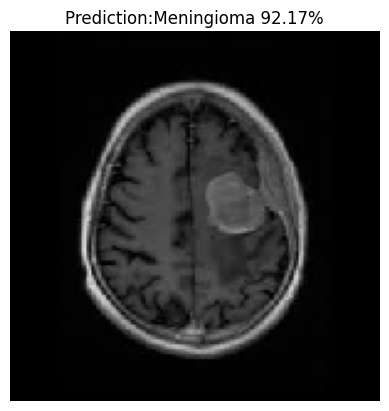

In [14]:
img = load_img(img_path, target_size=(150, 150))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0


prediction=model.predict(img_array)
predicted_index=np.argmax(prediction,axis=1)[0]
predicted_label=class_labels[predicted_index]
confidence=np.max(prediction)*100
print(f"\nPredicted Class: {predicted_label}")
print(f"Confidence: {confidence:.2f}%")
plt.imshow(img)
plt.title(f"Prediction:{predicted_label} {confidence:.2f}%")
plt.axis("off")
plt.show()

Conclusion

In this project, a deep learning model was successfully developed for brain tumor detection and classification using MRI images. Data augmentation techniques were applied to enhance the dataset and improve the model’s generalization ability.

The model was trained for 20 epochs and achieved an accuracy of 94.94%, which shows that it can effectively classify different types of brain tumors. The system is capable of predicting tumor types such as Glioma, Meningioma, Pituitary tumor, and No Tumor with high confidence. For example, the model predicted a sample image as Meningioma with a confidence of 92.17%.

Overall, the proposed system provides a fast, accurate, and automated solution for brain tumor detection. It can assist doctors in diagnosis and reduce the chances of human error. In the future, the model can be further improved by using larger datasets and more advanced deep learning techniques to increase accuracy and reliability.